In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')

In [10]:
df = pd.read_csv('Mall_Customers.csv')

print(df.head())
print("-----------------------------------------------------\n")
print(df.info())
print("-----------------------------------------------------\n")
print(df.describe())
print("-----------------------------------------------------\n")

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
-----------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
N

In [12]:
df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})

df = df.drop('CustomerID', axis=1)

print(df.head())

   Gender  Age  Annual_Income  Spending_Score
0       1   19             15              39
1       1   21             15              81
2       0   20             16               6
3       0   23             16              77
4       0   31             17              40


In [13]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

print(df.head())

   Gender  Age  Annual_Income  Spending_Score
0       1   19             15              39
1       1   21             15              81
2       0   20             16               6
3       0   23             16              77
4       0   31             17              40


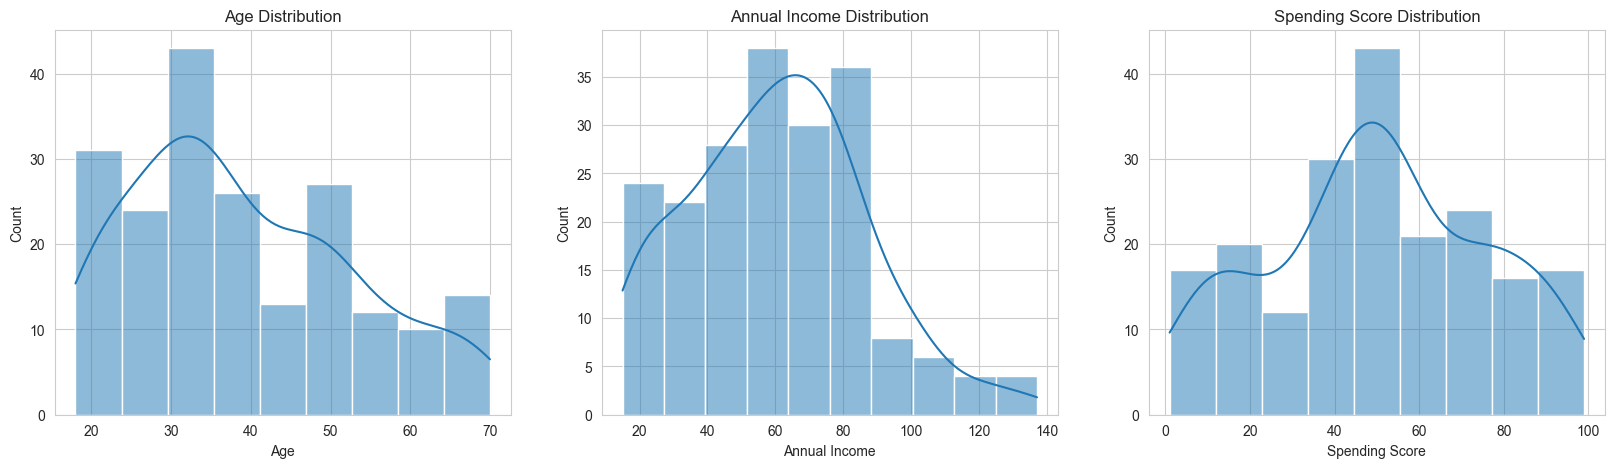

<Figure size 640x480 with 0 Axes>

In [47]:
plt.figure(figsize=(20,5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(df['Annual_Income'], kde=True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(df['Spending_Score'], kde=True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Count')
plt.show()

plt.tight_layout()
plt.show()

<Figure size 2000x500 with 0 Axes>

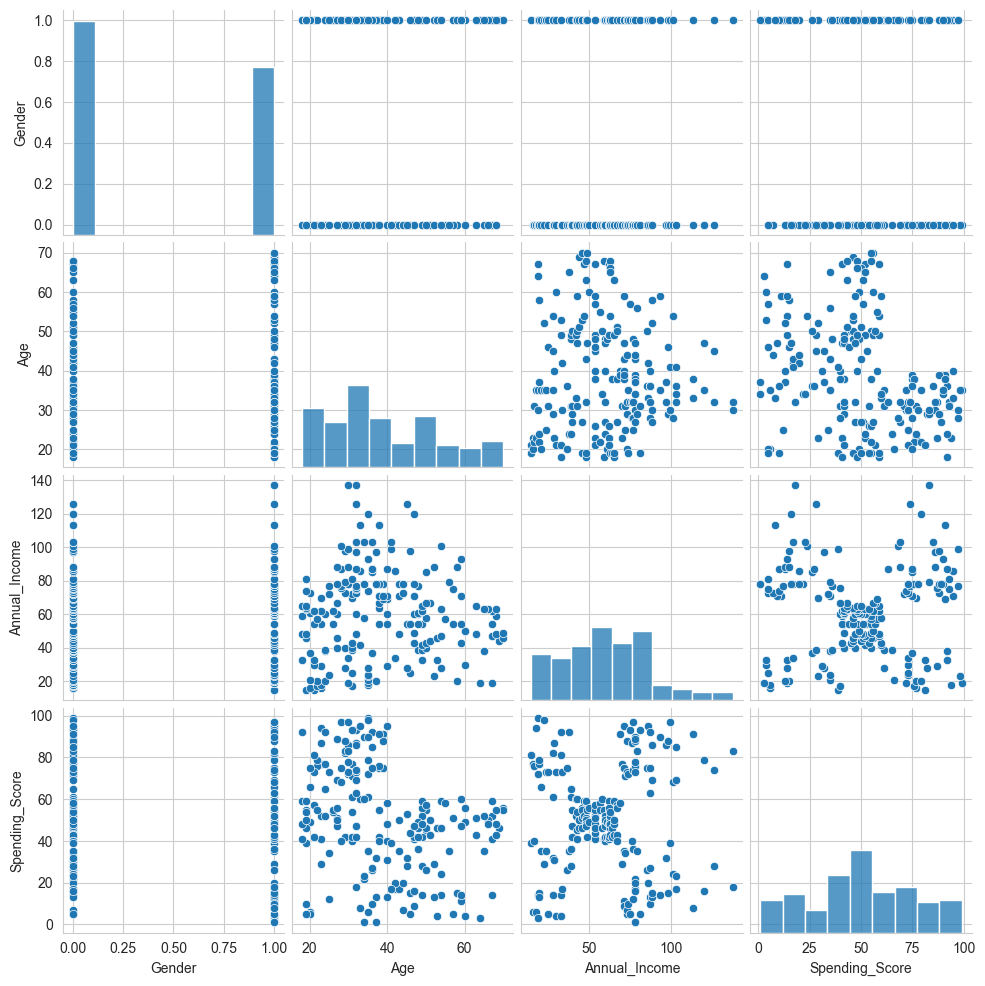

In [49]:
plt.figure(figsize=(20,5))
sns.pairplot(df)
plt.show()

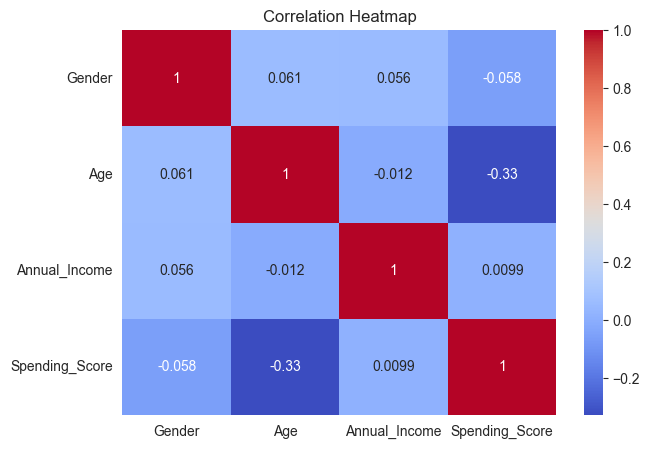

In [50]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [51]:
features = ['Age', 'Annual_Income', 'Spending_Score']

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[features]),
    columns=features
)

print(df_scaled.head())

        Age  Annual_Income  Spending_Score
0 -1.424569      -1.738999       -0.434801
1 -1.281035      -1.738999        1.195704
2 -1.352802      -1.700830       -1.715913
3 -1.137502      -1.700830        1.040418
4 -0.563369      -1.662660       -0.395980


In [52]:
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]

print(df_2f.head())

   Annual_Income  Spending_Score
0      -1.738999       -0.434801
1      -1.738999        1.195704
2      -1.700830       -1.715913
3      -1.700830        1.040418
4      -1.662660       -0.395980


In [77]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df_2f)
    inertia.append(kmeans.inertia_)

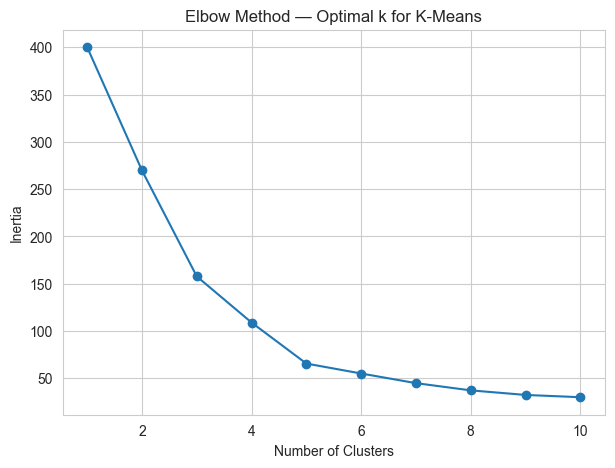

In [78]:
plt.figure(figsize=(7,5))

plt.plot(range(1, 11), inertia, marker='o')

plt.title('Elbow Method — Optimal k for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [55]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(df_2f)
    
    score = silhouette_score(df_2f, labels)
    silhouette_scores.append(score)

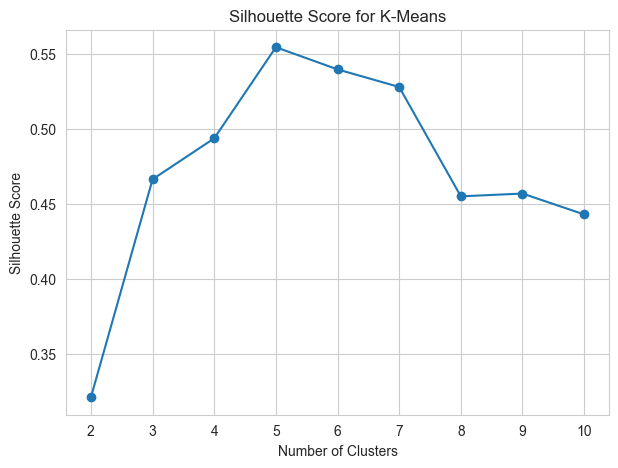

In [56]:
plt.figure(figsize=(7,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.show()

In [57]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best K:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K: 5
Best Silhouette Score: 0.5546571631111091


In [58]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(df_2f)

print(df.head())

   Gender  Age  Annual_Income  Spending_Score  KMeans_Cluster
0       1   19             15              39               4
1       1   21             15              81               2
2       0   20             16               6               4
3       0   23             16              77               2
4       0   31             17              40               4


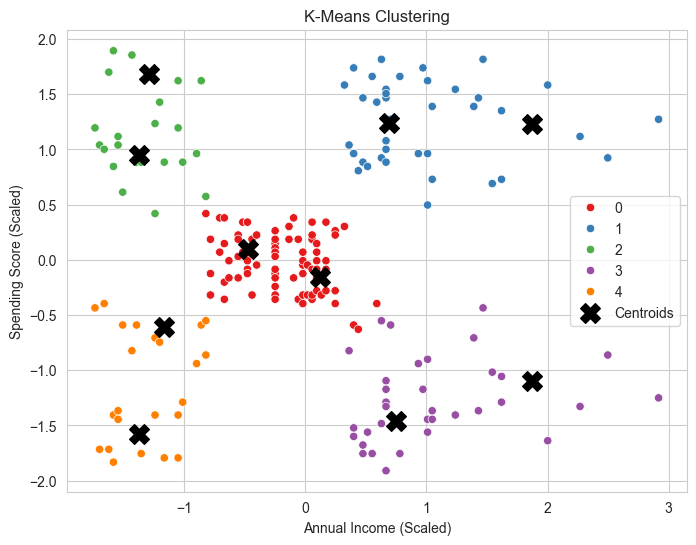

In [85]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_2f['Annual_Income'],
    y=df_2f['Spending_Score'],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title('K-Means Clustering')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()

plt.show()

In [60]:
kmeans_profile = df.groupby('KMeans_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean()

kmeans_profile

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


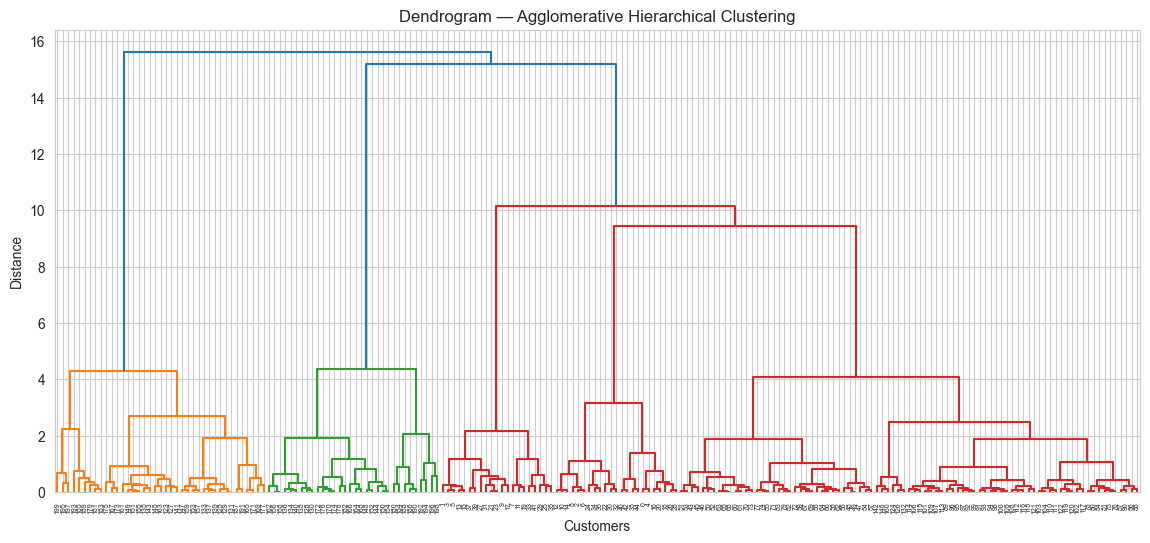

In [61]:
linked = linkage(df_2f, method='ward')

plt.figure(figsize=(14,6))

dendrogram(linked)

plt.title('Dendrogram — Agglomerative Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')

plt.show()

In [62]:
hier = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

df['Hier_Cluster'] = hier.fit_predict(df_2f)

print(df.head())

   Gender  Age  Annual_Income  Spending_Score  KMeans_Cluster  Hier_Cluster
0       1   19             15              39               4             4
1       1   21             15              81               2             3
2       0   20             16               6               4             4
3       0   23             16              77               2             3
4       0   31             17              40               4             4


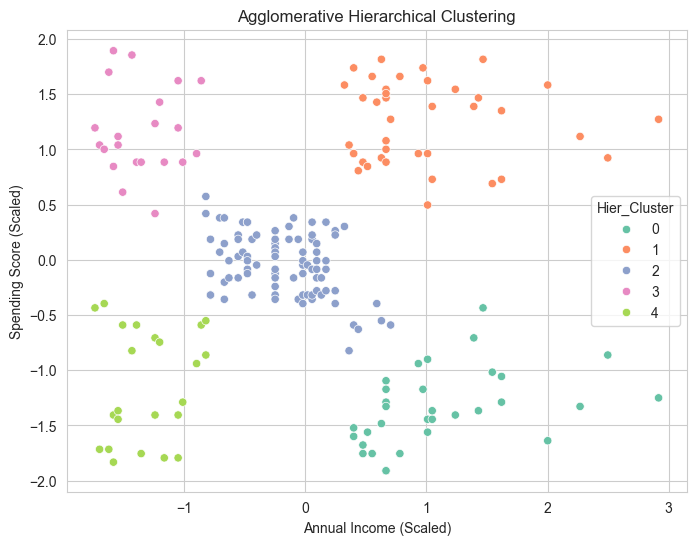

In [63]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_2f['Annual_Income'],
    y=df_2f['Spending_Score'],
    hue=df['Hier_Cluster'],
    palette='Set2'
)

plt.title('Agglomerative Hierarchical Clustering')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')

plt.show()

In [64]:
hier_profile = df.groupby('Hier_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean()

hier_profile

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.000000,89.406250,15.593750
1,32.692308,86.538462,82.128205
2,42.482353,55.811765,49.129412
3,25.333333,25.095238,80.047619
4,45.217391,26.304348,20.913043


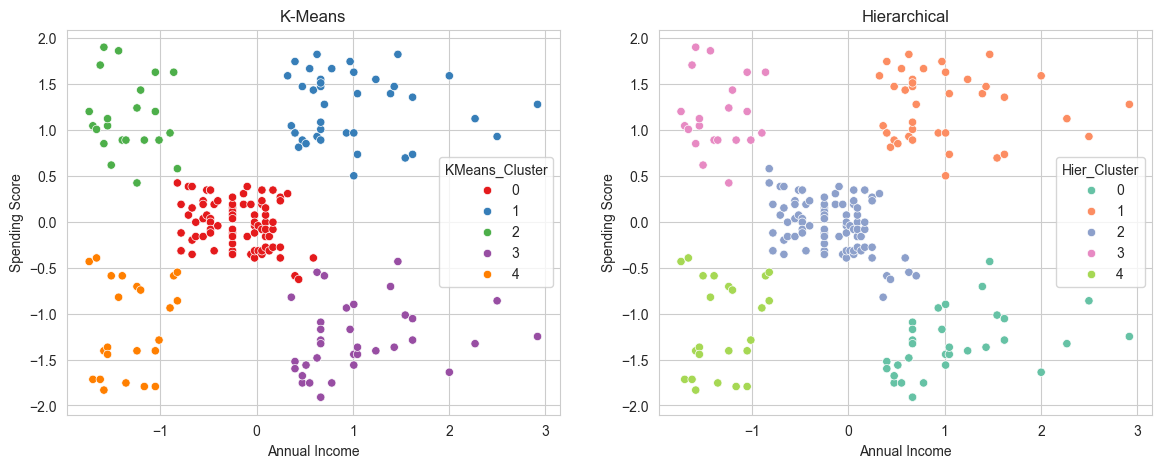

In [65]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

sns.scatterplot(
    x=df_2f['Annual_Income'],
    y=df_2f['Spending_Score'],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.title('K-Means')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')


plt.subplot(1,2,2)

sns.scatterplot(
    x=df_2f['Annual_Income'],
    y=df_2f['Spending_Score'],
    hue=df['Hier_Cluster'],
    palette='Set2'
)

plt.title('Hierarchical')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

In [74]:
kmeans_score = silhouette_score(
    df_2f,
    df['KMeans_Cluster']
)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.5546571631111091


In [71]:
hier_score = silhouette_score(
    df_2f,
    df['Hier_Cluster']
)

print("Hierarchical Silhouette Score:", hier_score)

Hierarchical Silhouette Score: 0.5538089226688662


In [72]:
scores = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical'],
    'Silhouette Score': [kmeans_score, hier_score]
})

scores

,Algorithm,Silhouette Score
0,K-Means,0.554657
1,Hierarchical,0.553809


In [73]:
df.groupby('KMeans_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean().round(2)

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91
